# Fitness Activity Segmentation using K-Means Clustering
### Data Science Mini Project

**Objective:** Segment users based on fitness activity metrics using unsupervised machine learning (K-Means clustering).

In [18]:
import os
os.environ["OMP_NUM_THREADS"] = "4"
import warnings
warnings.filterwarnings("ignore")

## 1. Import Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## 2. Load Dataset

In [20]:
df = pd.read_csv('dailyActivity_merged.csv')
df.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [21]:
df.columns

Index(['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance',
       'LoggedActivitiesDistance', 'VeryActiveDistance',
       'ModeratelyActiveDistance', 'LightActiveDistance',
       'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes',
       'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories'],
      dtype='object')

## 3. Dataset Understanding
This dataset contains daily fitness activity collected from Fitbit devices including steps, calories burned, and activity minutes.

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    object 
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940 non-null    int64  
 14  Calories  

In [23]:
df.describe()

,Id,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
count,9.400000e+02,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000
mean,4.855407e+09,7637.910638,5.489702,5.475351,0.108171,1.502681,0.567543,3.340819,0.001606,21.164894,13.564894,192.812766,991.210638,2303.609574
std,2.424805e+09,5087.150742,3.924606,3.907276,0.619897,2.658941,0.883580,2.040655,0.007346,32.844803,19.987404,109.174700,301.267437,718.166862
min,1.503960e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.320127e+09,3789.750000,2.620000,2.620000,0.000000,0.000000,0.000000,1.945000,0.000000,0.000000,0.000000,127.000000,729.750000,1828.500000
50%,4.445115e+09,7405.500000,5.245000,5.245000,0.000000,0.210000,0.240000,3.365000,0.000000,4.000000,6.000000,199.000000,1057.500000,2134.000000
75%,6.962181e+09,10727.000000,7.712500,7.710000,0.000000,2.052500,0.800000,4.782500,0.000000,32.000000,19.000000,264.000000,1229.500000,2793.250000
max,8.877689e+09,36019.000000,28.030001,28.030001,4.942142,21.920000,6.480000,10.710000,0.110000,210.000000,143.000000,518.000000,1440.000000,4900.000000


## 4. Data Cleaning

In [24]:
df.isnull().sum()

Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64

In [25]:
df = df.dropna()

## 5. Feature Selection for Clustering

In [26]:
data = df[['TotalSteps','TotalDistance','Calories','VeryActiveMinutes','FairlyActiveMinutes','LightlyActiveMinutes','SedentaryMinutes']]
data.head()

,TotalSteps,TotalDistance,Calories,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes
0,13162,8.50,1985,25,13,328,728
1,10735,6.97,1797,21,19,217,776
2,10460,6.74,1776,30,11,181,1218
3,9762,6.28,1745,29,34,209,726
4,12669,8.16,1863,36,10,221,773


## 6. Feature Scaling

In [27]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

## 7. Exploratory Data Analysis

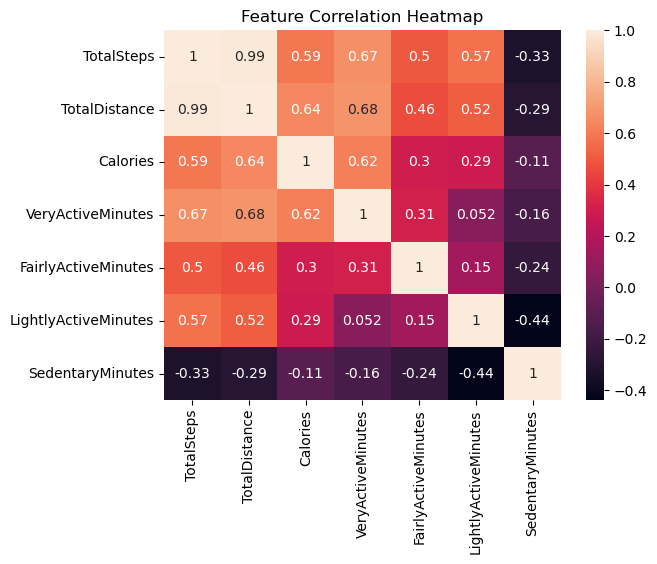

In [28]:
plt.figure()
sns.heatmap(data.corr(), annot=True)
plt.title('Feature Correlation Heatmap')
plt.show()

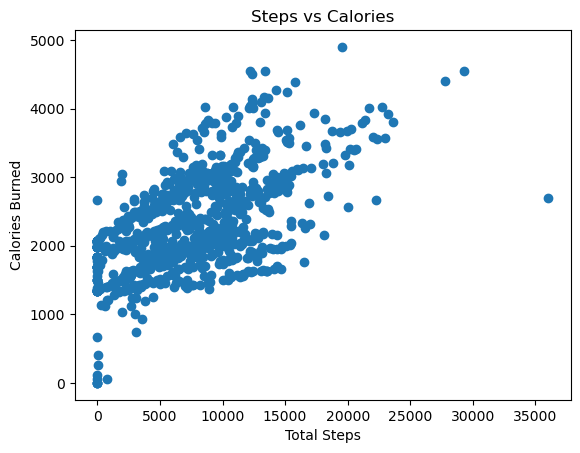

In [29]:
plt.figure()
plt.scatter(data['TotalSteps'], data['Calories'])
plt.xlabel('Total Steps')
plt.ylabel('Calories Burned')
plt.title('Steps vs Calories')
plt.show()

In [30]:
wcss = []

for i in range(1,10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

## 8. Apply K-Means Clustering

In [31]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

data['Cluster'] = clusters
data.head()

,TotalSteps,TotalDistance,Calories,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Cluster
0,13162,8.50,1985,25,13,328,728,2
1,10735,6.97,1797,21,19,217,776,2
2,10460,6.74,1776,30,11,181,1218,2
3,9762,6.28,1745,29,34,209,726,2
4,12669,8.16,1863,36,10,221,773,2


## 9. Cluster Visualization

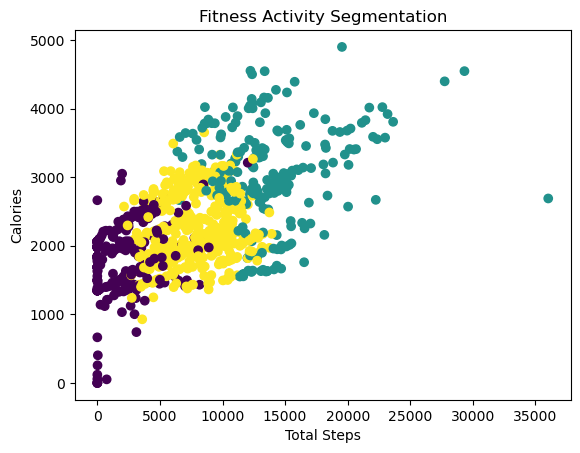

In [32]:
plt.figure()
plt.scatter(data['TotalSteps'], data['Calories'], c=data['Cluster'])
plt.xlabel('Total Steps')
plt.ylabel('Calories')
plt.title('Fitness Activity Segmentation')
plt.show()

## 10. Cluster Distribution

In [33]:
data['Cluster'].value_counts()

Cluster
2    459
0    263
1    218
Name: count, dtype: int64

## 11. Conclusion

This project used K-Means clustering to group users based on fitness activity metrics.

The algorithm segmented users into different clusters representing different activity levels:
- Highly active users
- Moderately active users
- Low activity users

These insights can help fitness companies provide personalized workout plans and health recommendations.